In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import drive
from tqdm import tqdm
import dlib
#!pip install mediapipe
#import mediapipe as mp
import seaborn as sns
from scipy.fftpack import fft2, fftshift
from scipy import ndimage
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
from PIL import Image
from time import time
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from skimage.feature import hog
from imutils import face_utils
import argparse
import imutils
import cv2
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bunzip2 shape_predictor_68_face_landmarks.dat.bz2

!pip install insightface onnxruntime
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
import time

from insightface.app import FaceAnalysis
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

--2025-12-12 16:01:17--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2025-12-12 16:01:18--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  17.0MB/s    in 4.5s    

2025-12-12 16:01:23 (13.7 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 8.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing

TODO

- test on on the validation set
- Add model type for each param tried
- Add Timer wrapper

In [4]:
path = "drive/MyDrive/datasci281/"
X_train = np.load(path + "X_train_arcface.npy")
y_train = np.load(path + "y_train_embeddings.npy")
X_test = np.load(path + "X_test_arcface.npy")
y_test = np.load(path + "y_test_embeddings.npy")

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#print("Scaled shape:", X_scaled.shape)

### Split the code Train and Validation Set

In [6]:
emotion_names = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
X_train, X_Val, y_train, y_Val = train_test_split(
    X_train,
    y_train,
    test_size=0.30,      # 30% goes to val
    random_state=42,
    stratify=y_train
)
print("Train shape:", X_train.shape)
print("Val shape:", X_Val.shape)

Train shape: (20096, 512)
Val shape: (8613, 512)


In [7]:
def check_distribution(name, labels):
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{name} distribution:")
    for u, c in zip(unique, counts):
        print(f"{emotion_names[int(u)]:>10}: {c}")

check_distribution("Train", y_train)
check_distribution("Validation", y_Val)



Train distribution:
     angry: 2797
   disgust: 305
      fear: 2868
     happy: 5050
       sad: 3381
  surprise: 2220
   neutral: 3475

Validation distribution:
     angry: 1198
   disgust: 131
      fear: 1229
     happy: 2165
       sad: 1449
  surprise: 951
   neutral: 1490


In [8]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    max_iter=2000,
    n_jobs=-1,
    multi_class="multinomial",
    class_weight="balanced"
)
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],   # regularization strength
    "solver": ["lbfgs", "saga"],         # compatible with multinomial
    "penalty": ["l2"]                    # safe + stable
}

In [9]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring="f1_macro",     # best metric for FER2013
    cv=5,
    verbose=2,
    n_jobs=-1
)

In [10]:
start = time.time()
grid_search.fit(X_train, y_train)
end = time.time()
print(f"Training time: {end - start:.4f} seconds")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Training time: 3098.2749 seconds


In [11]:
print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}


In [12]:
import joblib
joblib.dump(grid_search, 'grid_search_model.joblib')
joblib.dump(grid_search.best_estimator_, 'best_estimator.joblib')

['best_estimator.joblib']

In [13]:
best_clf = grid_search.best_estimator_

In [14]:
best_clf.predict(X_Val)
best_clf.predict_proba(X_Val)

array([[8.53730541e-02, 2.72662633e-07, 1.91984411e-01, ...,
        6.35540065e-01, 1.52473064e-03, 8.49091224e-02],
       [1.21289722e-02, 5.78904826e-01, 9.01086985e-03, ...,
        2.33868402e-01, 2.69530689e-04, 8.16392872e-02],
       [1.90789032e-01, 2.53671699e-08, 2.69498327e-02, ...,
        2.13945993e-01, 1.74870838e-02, 3.83951571e-01],
       ...,
       [2.11167180e-01, 1.63779441e-08, 1.11337308e-01, ...,
        7.18782719e-03, 4.88178089e-02, 1.63586016e-01],
       [1.64988022e-02, 1.35399348e-02, 4.38452328e-02, ...,
        4.96038714e-03, 7.67216873e-01, 1.37997484e-01],
       [1.38330344e-03, 7.01869142e-06, 6.77080474e-03, ...,
        3.03995549e-04, 9.83624364e-01, 4.20868400e-03]])

## lets test our best model

In [ ]:
# best_clf = LogisticRegression(
#     C=1,
#     penalty="l2",
#     solver="lbfgs",
#     max_iter=2000,              # Important for convergence
#     n_jobs=-1,
#     multi_class="multinomial",
#     class_weight="balanced",   # Important for FER class imbalance
#     random_state=42
# )

In [15]:
start = time.time()
best_clf.fit(X_train, y_train)

end = time.time()
print(f"Training time: {end - start:.4f} seconds")

Training time: 27.9857 seconds


In [26]:
best_clf.predict(X_train)
best_clf.predict_proba(X_train)

array([[4.00877586e-02, 1.23637411e-04, 1.80935246e-01, ...,
        6.81593050e-01, 2.87709753e-03, 6.18337881e-02],
       [8.62228021e-02, 2.64484997e-01, 3.99547498e-02, ...,
        1.16471646e-01, 2.30238798e-03, 4.78913348e-01],
       [8.63328753e-02, 1.47511377e-06, 8.41888262e-03, ...,
        3.43922521e-01, 5.18939461e-02, 4.88896240e-01],
       ...,
       [1.85332433e-01, 1.67507449e-02, 6.43677346e-02, ...,
        3.13739901e-02, 5.91853617e-02, 1.23562838e-01],
       [8.37901509e-03, 2.27237951e-05, 6.91869570e-03, ...,
        2.44765915e-02, 3.66158179e-04, 4.27833652e-03],
       [4.65480665e-03, 6.82593492e-07, 6.14607899e-02, ...,
        2.08005296e-01, 1.65499012e-02, 3.18709490e-01]])

In [27]:
train_acc = accuracy_score(y_train, best_clf.predict(X_train))
print("Train Accuracy:", train_acc)

Train Accuracy: 0.5525975318471338


# test on our validation data

In [16]:
from sklearn.metrics import accuracy_score
start = time.time()
val_preds = best_clf.predict(X_Val)
val_acc = accuracy_score(y_Val, val_preds)
end = time.time()
print(f"Inference time: {end - start:.4f} seconds")
print("Validation Accuracy:", val_acc)

Inference time: 0.0105 seconds
Validation Accuracy: 0.5006385696040868


In [17]:
print(X_Val.shape)
print(y_Val.shape)
print(type(best_clf))

(8613, 512)
(8613,)
<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [18]:
cm = confusion_matrix(y_Val, val_preds)
print(cm)

[[ 585   95  134   94  119   81   90]
 [  22   80   13    3    7    4    2]
 [ 177   58  385  108  195  175  131]
 [ 112   56  121 1328  111  171  266]
 [ 149   71  186  109  633   53  248]
 [  69   29   77   91   22  626   37]
 [ 115   34  122  252  230   62  675]]


<Figure size 640x480 with 0 Axes>

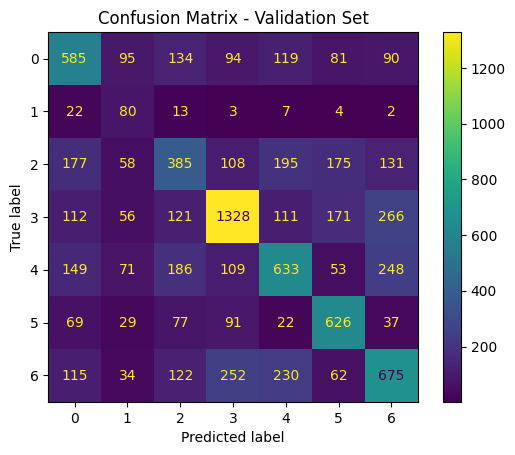

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure()
disp.plot()
plt.title("Confusion Matrix - Validation Set")
plt.show()

# Test on test data

In [21]:
start = time.time()
test_preds = best_clf.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)
end = time.time()
print(f"Inference time: {end - start:.4f} seconds")

print("Test Accuracy:", test_acc)

Inference time: 0.0128 seconds
Test Accuracy: 0.49791028141543603


In [22]:
print(classification_report(y_test, test_preds, target_names=emotion_names))

              precision    recall  f1-score   support

       angry       0.45      0.46      0.45       958
     disgust       0.17      0.64      0.27       111
        fear       0.36      0.31      0.33      1024
       happy       0.68      0.61      0.64      1774
         sad       0.49      0.43      0.46      1247
    surprise       0.57      0.67      0.62       831
     neutral       0.46      0.47      0.46      1233

    accuracy                           0.50      7178
   macro avg       0.45      0.51      0.46      7178
weighted avg       0.51      0.50      0.50      7178



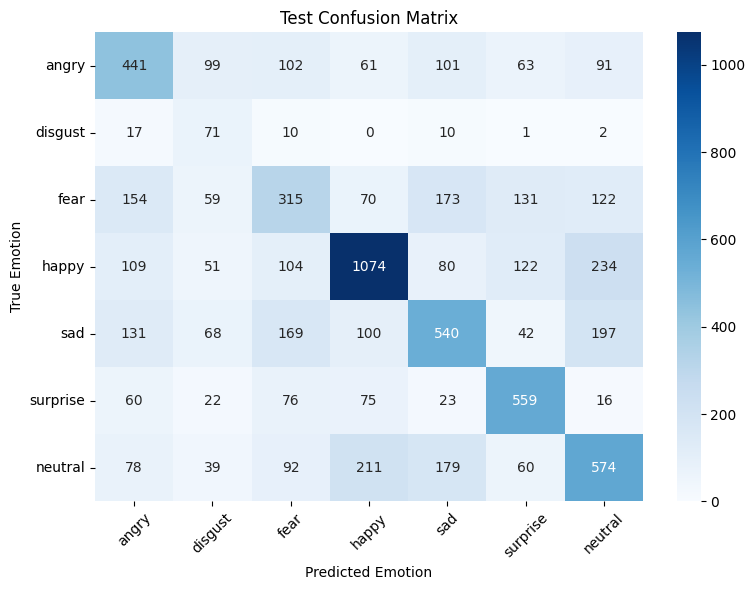

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=emotion_names,   # ✅ X-axis labels
    yticklabels=emotion_names    # ✅ Y-axis labels
)

plt.title("Test Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [24]:
y_score = best_clf.predict_proba(X_test)

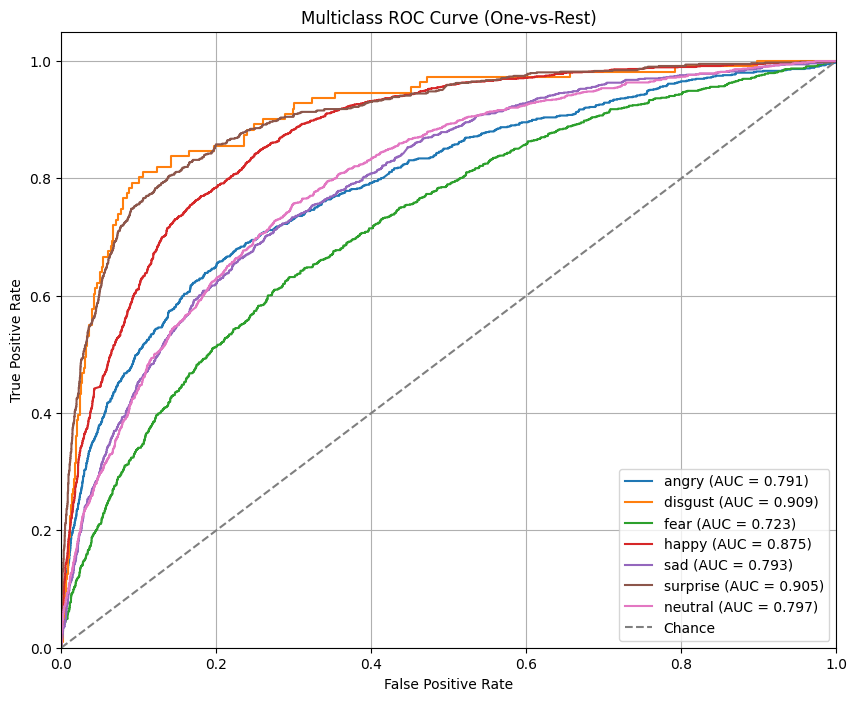

In [25]:
n_classes = len(emotion_names)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
plt.figure(figsize=(10, 8))

for i in range(len(emotion_names)):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{emotion_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

# Random chance line
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_test_bin.ravel(), y_score.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])


# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])


# Plot everything
plt.figure(figsize=(9, 7))

plt.plot(
    fpr["micro"],
    tpr["micro"],
    linestyle=":",
    label=f"Micro-average (AUC = {roc_auc['micro']:.3f})"
)

plt.plot(
    fpr["macro"],
    tpr["macro"],
    linestyle="--",
    label=f"Macro-average (AUC = {roc_auc['macro']:.3f})"
)

for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{emotion_names[i]}"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC with Micro & Macro Averages (Test Set)")
plt.legend()
plt.grid(True)
plt.show()
